<a href="https://colab.research.google.com/github/vyshnavivallepu7-code/Machine-learning/blob/main/glass_exp4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Load dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/glass/glass.data"
columns = ['Id', 'RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type']
df = pd.read_csv(url, names=columns)

df.head()

,Id,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,2,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,3,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,4,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,5,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


/tmp/ipykernel_3826/731505590.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Type', data=df, palette='viridis')


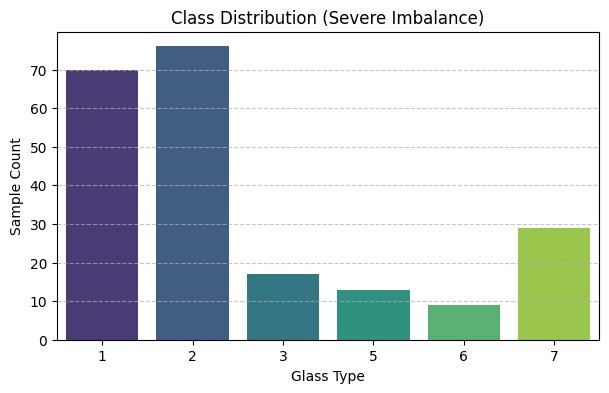

In [ ]:
# Drop redundant ID column
df = df.drop(columns=['Id'])
df

plt.figure(figsize=(7, 4))
sns.countplot(x='Type', data=df, palette='viridis')
plt.title("Class Distribution (Severe Imbalance)")
plt.xlabel("Glass Type")
plt.ylabel("Sample Count")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


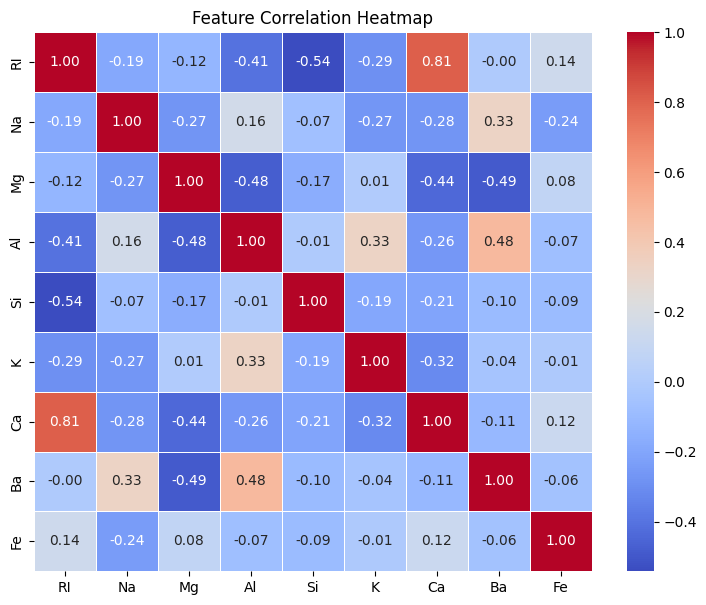

In [ ]:
plt.figure(figsize=(9, 7))
corr = df.drop(columns=['Type']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

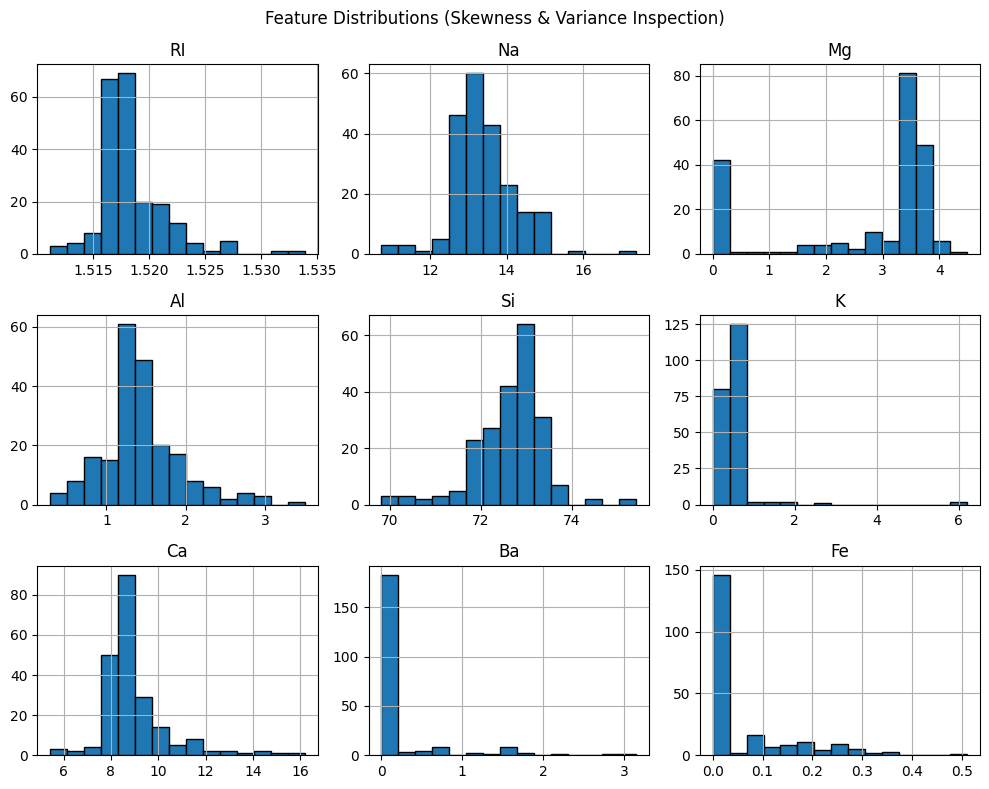

In [ ]:
df.drop(columns=['Type']).hist(figsize=(10, 8), bins=15, edgecolor='black')
plt.suptitle("Feature Distributions (Skewness & Variance Inspection)")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize

# Features and target
X = df.drop(columns=['Type'])
y = df['Type']
print("Attribute Set",X.head(5))
print("Class Labels",y.head(5))

Attribute Set         RI     Na    Mg    Al     Si     K    Ca   Ba   Fe
0  1.52101  13.64  4.49  1.10  71.78  0.06  8.75  0.0  0.0
1  1.51761  13.89  3.60  1.36  72.73  0.48  7.83  0.0  0.0
2  1.51618  13.53  3.55  1.54  72.99  0.39  7.78  0.0  0.0
3  1.51766  13.21  3.69  1.29  72.61  0.57  8.22  0.0  0.0
4  1.51742  13.27  3.62  1.24  73.08  0.55  8.07  0.0  0.0
Class Labels 0    1
1    1
2    1
3    1
4    1
Name: Type, dtype: int64


In [ ]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Encoded labels: ", y_encoded)
#
classes = np.unique(y_encoded)
n_classes = len(classes)
print("The number of classes in the dataset are: ", n_classes)

Encoded labels:  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3 4 4 4 4 4 4 4 4 4
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5]
The number of classes in the dataset are:  6


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.25, random_state=42, stratify=y_encoded
)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    roc_curve,
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Binarize test targets for multi-class ROC computation
y_test_bin = label_binarize(y_test, classes=classes)


================ Random Forest ================
Accuracy: 83.33%

              precision    recall  f1-score   support

      Type 1       0.77      0.94      0.85        18
      Type 2       0.88      0.74      0.80        19
      Type 3       1.00      0.50      0.67         4
      Type 5       0.67      0.67      0.67         3
      Type 6       0.67      1.00      0.80         2
      Type 7       1.00      1.00      1.00         8

    accuracy                           0.83        54
   macro avg       0.83      0.81      0.80        54
weighted avg       0.85      0.83      0.83        54

================ k-Nearest Neighbors ================
Accuracy: 81.48%

              precision    recall  f1-score   support

      Type 1       0.83      0.83      0.83        18
      Type 2       0.78      0.95      0.86        19
      Type 3       1.00      0.25      0.40         4
      Type 5       1.00      0.67      0.80         3
      Type 6       0.50      0.50      0.50     

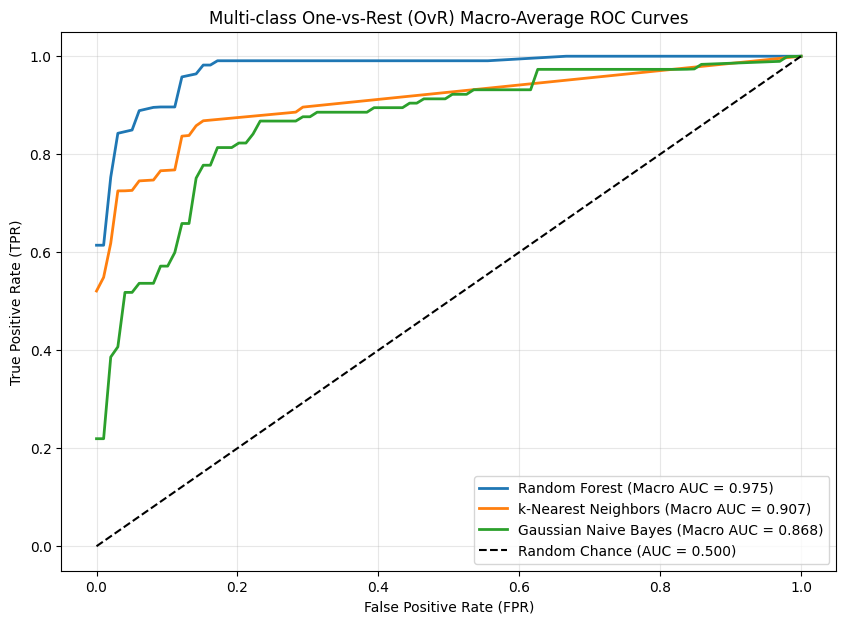

In [ ]:
# Define models
models = {
    "Random Forest": (RandomForestClassifier(n_estimators=100, random_state=42), X_train, X_test),
    "k-Nearest Neighbors": (KNeighborsClassifier(n_neighbors=3, weights='distance'), X_train_scaled, X_test_scaled),
    "Gaussian Naive Bayes": (GaussianNB(), X_train, X_test)
}

plt.figure(figsize=(10, 7))
for name, (clf, train_x, test_x) in models.items():
    # Fit model
    clf.fit(train_x, y_train)
    y_pred = clf.predict(test_x)
    y_proba = clf.predict_proba(test_x)

    # Classification Metrics
    print(f"================ {name} ================")
    print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
    print(classification_report(y_test, y_pred, target_names=[f"Type {c}" for c in le.classes_], zero_division=0))

    # Compute Macro-Average ROC-AUC
    fpr_grid = np.linspace(0.0, 1.0, 100)
    mean_tpr = np.zeros_like(fpr_grid)

    for i in range(n_classes):
        fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        mean_tpr += np.interp(fpr_grid, fpr_i, tpr_i)

    mean_tpr /= n_classes
    macro_auc = auc(fpr_grid, mean_tpr)

    # Plot Macro-Average ROC Curve
    plt.plot(fpr_grid, mean_tpr, label=f"{name} (Macro AUC = {macro_auc:.3f})", linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label="Random Chance (AUC = 0.500)")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Multi-class One-vs-Rest (OvR) Macro-Average ROC Curves")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()